### Projeto 02 - Arte dos dados

---
Aluno: Juan Pablo Moreno Oliveira



#### Preparação do ambiente e dados

##### Obtenção dos dados:

A importação do dataset poderia se dar de muitas maneiras, como por exemplo o armazenamento do código no meu drive e acesso por permissão, acesso local ou um git clone do repositório. Como as duas primeiras opções dificultariam a reprodução do ambiente em outras máquinas, o melhor é criar um clone do repositório no ambiente virtual, o que garante a verificação. Meu primeiro passo vai ser clonar o repositório que usaremos. Após isso irei imprimir o README do projeto para executarmos. Então irei extrair as informações do que deve ser feito para organizar o relatório.

In [0]:
#Clonando o repositório para acesso pelo colab
#!git clone https://github.com/MathMachado/DSWP.git #remova o comentário na primeira execução em outra máquina

In [0]:
#Arquivos na nossa pasta
print("pasta mãe")
!ls DSWP/Projetos/
print("pasta filha") # A que se refere ao nosso projeto em questão
!ls DSWP/Projetos/Projeto2
#Parece que o README geral está na pasta mãe do projeto 'DSWP/Projetos/'
#então ela é a que iremos usar para buscar nossos objetivos
file =  open("DSWP/Projetos/README.md", "r", encoding="utf-8")
conteudo_md = file.read()
#print(conteudo_md) #esta linha vai ser comentada pois o que cabe apenas ao projeto 02 será definido como texto á frente

pasta mãe
Projeto2  Projeto3  README.md
pasta filha
car_insurance_premium_dataset.csv	readme.md
car_insurance_premium_dataset_TEST.csv


In [0]:
#Nos mudando para a pasta do projeto 2
%cd DSWP/Projetos/Projeto2

/Workspace/Users/jufln.me@gmail.com/DSWP/Projetos/Projeto2


/databricks/python/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


##### Bibliotecas

As bibliotecas que precisei importar ao longo do projetos serão listadas e importadas nessa seção.

In [0]:
!pip install pyod # uso: aplicada na aula de ANOMALY/OUTLIER DETECTION
import pandas as pd  # uso: para ler, manipular e analisar dados em tabelas (DataFrames)
import numpy as np  # uso: para realizar cálculos numéricos e operações com arrays
import matplotlib.pyplot as plt  # uso: para criar gráficos
import seaborn as sns  # uso: para gerar gráficos de melhor vizualização (ainda decidindo entre sns e plt)
import re #uso: para regex
from sklearn.ensemble import IsolationForest

# Scaling variables
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Para fazer o teste t
from scipy.stats import ttest_ind

#Para regressão
import statsmodels.api as sm
import statsmodels.formula.api as smf

#from pyod.models.feature_bagging import FeatureBagging
from pyod.models.hbos import HBOS
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
#from pyod.models.lof import LOF
from scipy import stats

# remove warnings to keep notebook clean
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


#### Projeto: Car Insurance Premium Prediction

Objetivo: criar o pipeline de tratamento dos dados para construção dos modelos de Machine Learning. O Modelo a ser construido será um modelo de GLM (Modelos Lineares Generalizados) para predição dos prêmios, mas não se preocupe com o modelo nesta entrega. O foco é tratar os dados.

Este conjunto de dados contém 1.000 linhas de dados sintéticos que simulam prêmios de seguro de automóveis, calculados usando uma fórmula linear. Ele incorpora características-chave como idade do motorista, experiência de direção, histórico de acidentes, quilometragem anual e ano de fabricação do carro para prever o prêmio do seguro.
O conjunto de dados é ideal para explorar modelos de regressão linear, análise de importância de características e modelagem preditiva no setor de seguros. Ele foi inspirado em fatores do mundo real que influenciam os prêmios de seguro, garantindo padrões realistas e insights significativos.



##### Dados de treinamento e test dos modelos de ML
* Dados de treinamento do ML: car_insurance_premium_dataset.csv
* Dados de test do ML: car_insurance_premium_dataset_TEST.csv



Foi criado no workspace do projeto um diretório 'DataLake' no qual estarão todos os nossos dados, ordenados por bronze (raw), silver (com modificações) e gols (completamente tratado).


In [0]:
#Armazenando o data set de treinamento e teste no ambiente e observando o cabeçalho
base_path = "/Workspace/Users/jufln.me@gmail.com"
data_set_treinamento = pd.read_csv(f"{base_path}/DSWP/Projetos/Projeto2/car_insurance_premium_dataset.csv")
display(data_set_treinamento.head())
data_set_teste = pd.read_csv(f"{base_path}/DSWP/Projetos/Projeto2/car_insurance_premium_dataset_TEST.csv")
display(data_set_teste.head())

#Vamos Salvar nossos dados brutos na camada Bronze
data_set_treinamento.to_csv(f"{base_path}/DataLake/bronze/data_set_treinamento.csv")
data_set_teste.to_csv(f"{base_path}/DataLake/bronze/data_set_teste.csv")

Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age,Insurance Premium ($)
56,32,4,17,2002,23,488.35
46,19,0,21,2025,0,486.15
32,11,4,15,2020,5,497.55
60,0,4,19,1991,34,498.35
25,7,0,13,2005,20,495.55


Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age,Insurance Premium ($)
56,7,0,22,2009,16,489.4
46,23,2,21,1990,35,491.45
32,10,5,13,1997,28,501.55
60,16,1,16,2005,20,487.5
25,7,4,17,2003,22,501.95


##### Tarefas a serem feitas

**1. Aplicar lowercase em todas as colunas**

In [0]:
#Aplicação de uma função para automatiar o processo:
def to_lower(df):
  """
  Objetivo: Colocar todas as colunas em lowercase
  Input: Dataframe
  Output: Dataframe com todas as colunas em lowercase
  """
  df.columns = df.columns.str.lower()
  return df

#como o output é um novo Dataset, vamos sobrepor sua atual versão
data_set_treinamento_lower = to_lower(data_set_treinamento)
date_set_teste_lower = to_lower(data_set_teste)

#Exibindo o resultado
display(data_set_treinamento.head(1))
display(data_set_teste.head(1))

#Salvando os dados, agora na camada Silver
data_set_treinamento.to_csv(f"{base_path}/DataLake/silver/data_set_treinamento_lower.csv")
data_set_teste.to_csv(f"{base_path}/DataLake/silver/data_set_teste_lower.csv")

driver age,driver experience,previous accidents,annual mileage (x1000 km),car manufacturing year,car age,insurance premium ($)
56,32,4,17,2002,23,488.35


driver age,driver experience,previous accidents,annual mileage (x1000 km),car manufacturing year,car age,insurance premium ($)
56,7,0,22,2009,16,489.4


___

**2. Excluir caracteres especiais dos nomes das colunas, incluindo o espaço em branco entre nome de colunas**


In [0]:
def padronize_lower_case(df):
  """
  Objetivo: Padronizar os nomes das colunas usando regex
  Input: Dataframe
  Output: Dataframe com nomes de colunas padronizados: minusculo, sem caracteres especiais e separado por underscore.
  """
  # Define um padrão regex para tratar os caracteres especiais
  caracteres_especiais = r'[!@#$%"\'\(\)\*\+,\.\/:;<=>\?@\[\\\]\^`{\|}\~]' # Caracteres especiais (exceto underscore)
  df.columns = df.columns.str.lower()                                       # Aplica lowercase
  df.columns = df.columns.str.replace(caracteres_especiais, '', regex=True) # Remove caracteres especiais
  df.columns = df.columns.str.strip()                                       # Remove espaços desnecessários
  df.columns = df.columns.str.replace(" ", "_")                             # Troca espaços por underscore para manter o padrão
  return df

In [0]:
#Aplicando a função 
data_set_treinamento_padronizado = padronize_lower_case(data_set_treinamento_lower)
data_set_teste_padronizado = padronize_lower_case(date_set_teste_lower)

#Exibindo os cabeçalhos
display(data_set_treinamento_padronizado.head(1))
display(data_set_teste_padronizado.head(1))

#Salvando nossos dados na camada Silver
data_set_treinamento.to_csv(f"{base_path}/DataLake/silver/data_set_treinamento_padronized.csv")
data_set_teste.to_csv(f"{base_path}/DataLake/silver/data_set_teste_padronized.csv")


driver_age,driver_experience,previous_accidents,annual_mileage_x1000_km,car_manufacturing_year,car_age,insurance_premium
56,32,4,17,2002,23,488.35


driver_age,driver_experience,previous_accidents,annual_mileage_x1000_km,car_manufacturing_year,car_age,insurance_premium
56,7,0,22,2009,16,489.4


___


**3. Tratamento dos missing values para cada uma das variáveis do dataset. Substitua os missing values por mediana**


Nosso primeiro passo é encontrar a soma de ocorrências de is.na em cada variável

In [0]:
display(data_set_teste_padronizado.isna().sum())
print("\n")
display(data_set_treinamento_padronizado.isna().sum())

driver_age                 0
driver_experience          0
previous_accidents         0
annual_mileage_x1000_km    0
car_manufacturing_year     0
car_age                    0
insurance_premium          0
dtype: int64

driver_age                 0
driver_experience          0
previous_accidents         0
annual_mileage_x1000_km    0
car_manufacturing_year     0
car_age                    0
insurance_premium          0
dtype: int64

Nenhuma ocorrência, mas ainda podemos encontrar o equivalente numérico do 'NaN', como por exemplo uma idade valer 0. Vamos observar essa possibilidade nos próximos displays, ao verificar a soma de valores '0' e 'null'. 

In [0]:
display(data_set_treinamento_padronizado.eq(0).sum())
print("\n")
display(data_set_teste_padronizado.eq(0).sum())

driver_age                   0
driver_experience           47
previous_accidents         154
annual_mileage_x1000_km      0
car_manufacturing_year       0
car_age                     32
insurance_premium            0
dtype: int64

driver_age                  0
driver_experience           5
previous_accidents         23
annual_mileage_x1000_km     0
car_manufacturing_year      0
car_age                     2
insurance_premium           0
dtype: int64

Percebemos que todas as colunas que possuem valores 0 não devem ser considerados Na's. 
  - driver_experience: motoristas que começaram a dirigir há menos de um ano se encaixam
  - previous accidents: motoristas sem acidentes são muito comuns
  - car_age: carros lançados neste ano tem menos de um ano de fabricação

In [0]:
display(data_set_treinamento_padronizado.isnull().sum())
print("\n")
display(data_set_teste_padronizado.isnull().sum())

driver_age                 0
driver_experience          0
previous_accidents         0
annual_mileage_x1000_km    0
car_manufacturing_year     0
car_age                    0
insurance_premium          0
dtype: int64

driver_age                 0
driver_experience          0
previous_accidents         0
annual_mileage_x1000_km    0
car_manufacturing_year     0
car_age                    0
insurance_premium          0
dtype: int64

Ainda não parece ter nenhum dado fora do normal. Para que não restem duvidas vamos buscar anomalias que se encaixem no contexto de cada uma das colunas.

In [0]:
def verifica_nans(df):
    """
    Validações de realidade seguindo o padrão estabelecido
    """
    resultado = df.query(
        # Idade biologicamente impossível
        '(driver_age < 16 | driver_age > 100) | '
        
        # Experiência maior que idade (impossível)
        '(driver_experience > driver_age) | '
        
        # Começou a dirigir antes da idade legal
        '(driver_age - driver_experience < 16) | '
        
        # Carro do futuro ou muito antigo
        '(car_manufacturing_year > 2025 | car_manufacturing_year < 1900) | '
        
        # Idade do carro inconsistente
        '(2025 - car_manufacturing_year != car_age) | '
        
        # Experiência maior que idade (impossível)
        '(driver_experience > driver_age - 16) | '
        
        # Quilometragem anual impossível
        '(annual_mileage_x1000_km > 100 | annual_mileage_x1000_km < 0) | '
        
        # Número de acidentes impossível
        '(previous_accidents < 0 | previous_accidents > 50) | '
        
        # Prêmio de seguro impossível
        '(insurance_premium < 0 | insurance_premium > 10000) | '
        
        # Experiência zero mas com acidentes
        '(driver_experience == 0 & previous_accidents > 0) | '
        
        # Carro novo com idade inconsistente
        '(car_manufacturing_year > 2020 & car_age > 10) | '
        
        # Idade mínima mas com experiência
        '(driver_age == 16 & driver_experience > 0) | '

        # Fabricação com data indevida
        '(car_manufacturing_year == 0) |'
        
        # Quilometragem anual maior que limite possível
        '(annual_mileage_x1000_km > 50 & driver_experience < 1) '
    )
    
    return resultado

In [0]:
display(verifica_nans(data_set_teste_padronizado))
display(verifica_nans(data_set_treinamento_padronizado))

driver_age,driver_experience,previous_accidents,annual_mileage_x1000_km,car_manufacturing_year,car_age,insurance_premium
39,0,3,13,2024,1,497.45
45,0,1,22,2006,19,495.5
61,0,3,25,1999,26,496.15
18,0,5,22,1992,33,508.3


driver_age,driver_experience,previous_accidents,annual_mileage_x1000_km,car_manufacturing_year,car_age,insurance_premium
60,0,4,19,1991,34,498.35
38,0,5,13,2017,8,501.35
21,0,2,22,2001,24,502.3
18,0,2,16,2015,10,501.2
18,0,3,19,2000,25,504.35
18,0,4,18,2010,15,504.8
18,0,1,24,1999,26,501.7
30,0,3,25,2008,17,501.45
59,0,4,22,2018,7,496.0
18,0,4,11,2006,19,504.85


Manter a experiência zero como está - mesmo quando aparentemente contraditória com outros fatores, como kilometragem e acidentes anteriores - é fundamental porque:
- Reflete a realidade operacional do mercado de seguros
- Captura perfis de risco específicos que seriam perdidos se tratássemos como missing values
- Permite precificação mais precisa para casos complexos




___

**4. Tratamento dos outliers usando IQR e ZScore para cada da uma das variáveis do dataset. Substitua os outliers por mediana**

O primeiro passo para realizar ou não o tratamento de outliers é construirmos funções para verificar a existência destes outliers de fato. Então esse será nosso primeiro passo nesta seção, construir e testar a possibilidade da existência de outliers, para então tratá-los.

In [0]:
#vamos importar nossos dados diretamente da camada silver
train = pd.read_csv(f"{base_path}/DataLake/silver/data_set_treinamento_padronized.csv")
test = pd.read_csv(f"{base_path}/DataLake/silver/data_set_teste_padronized.csv")

Vamos primeiro dar uma olhada na **normalidade** das distribuições, já que não é confiável métodos como o Z-score em distribuições que não se assemelham com a normal

**_Normalidade - Dados teste_**

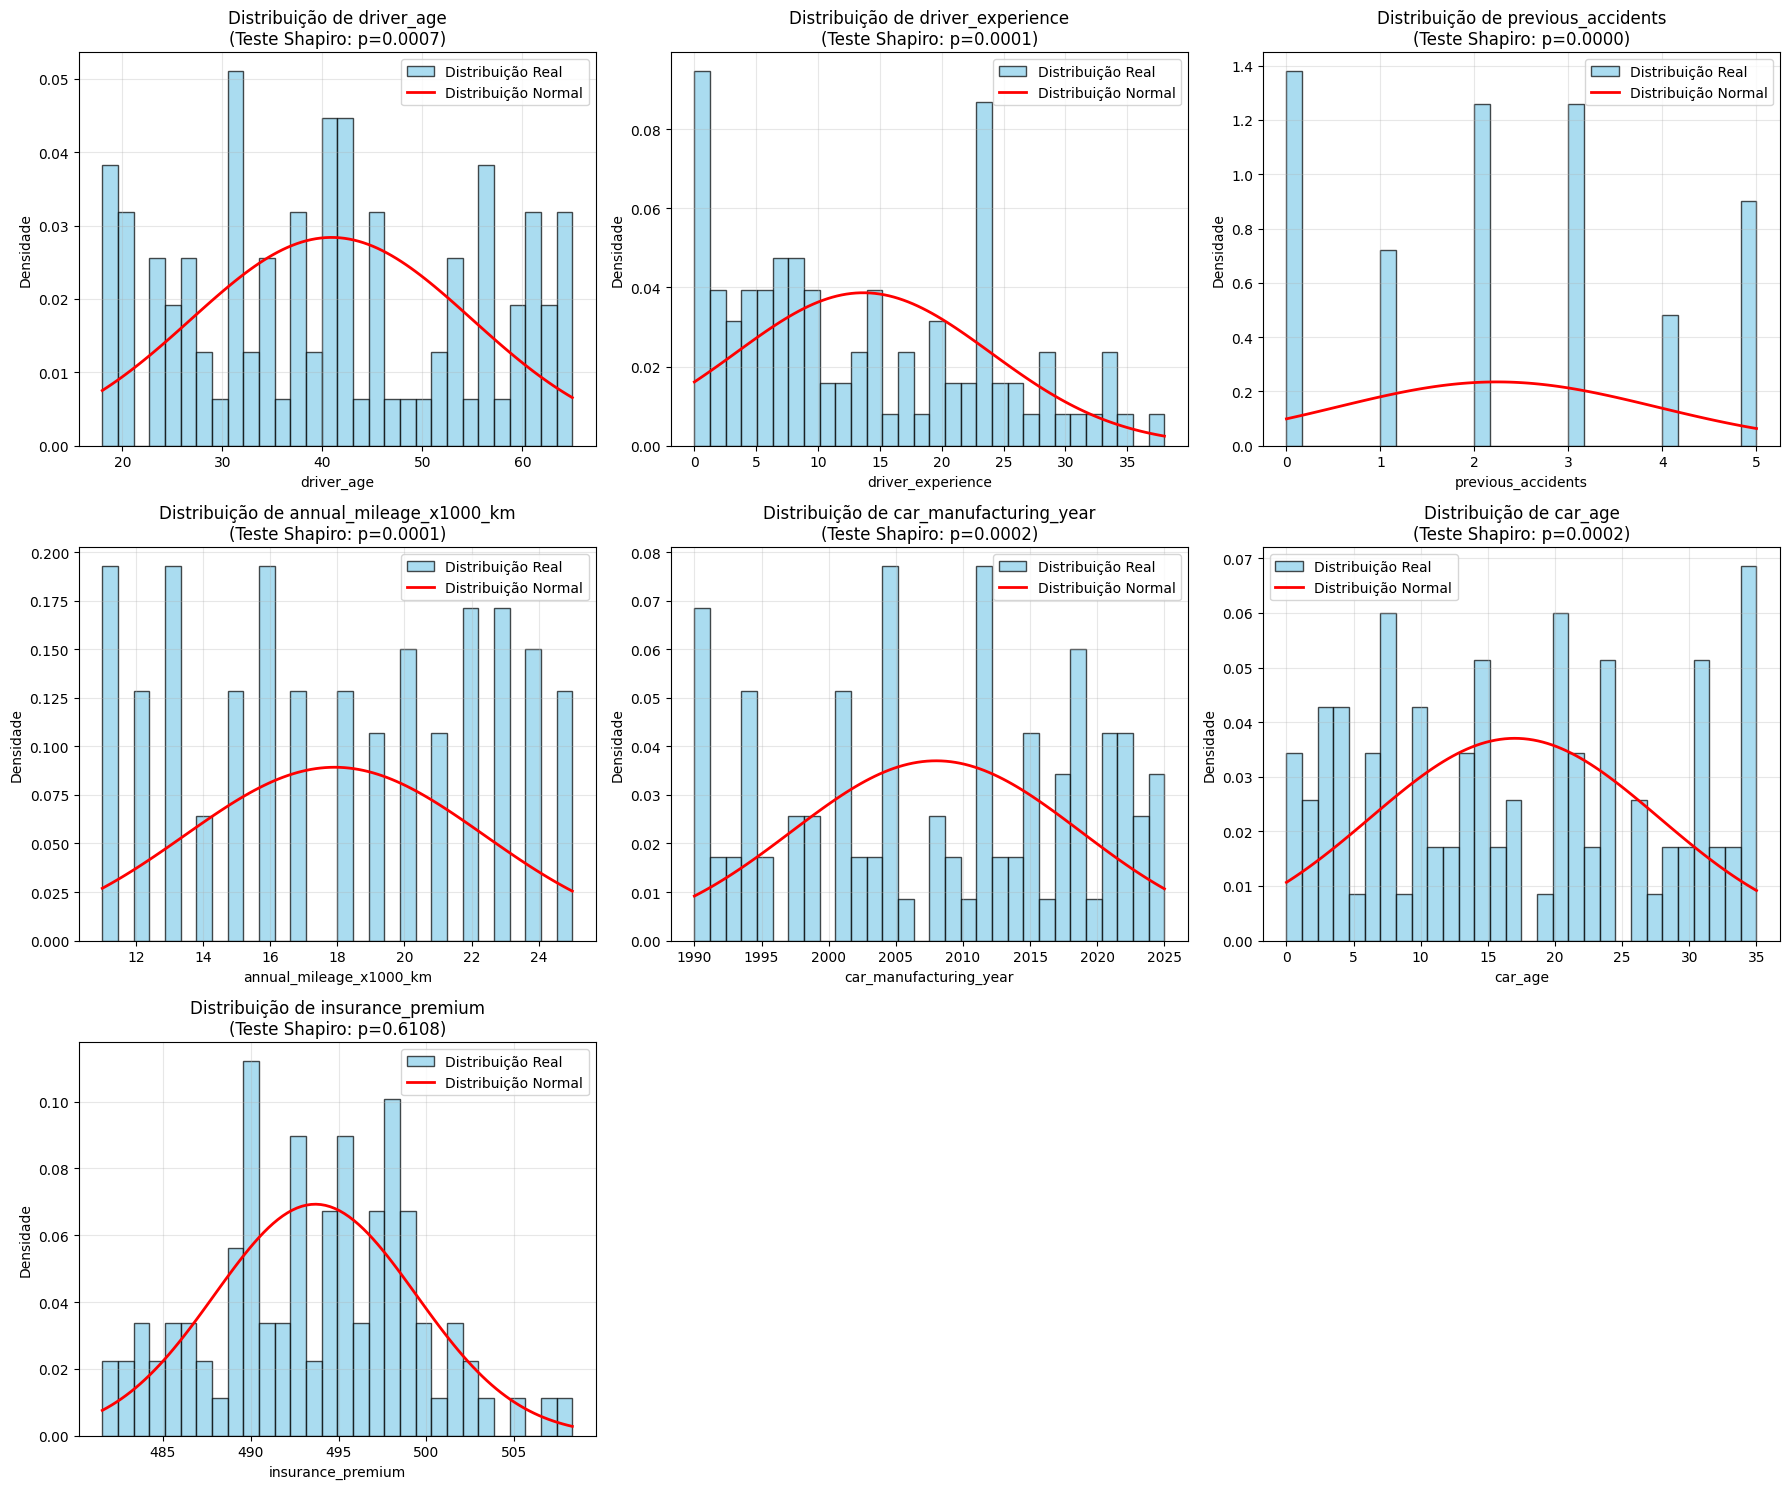

In [0]:
# Configuração para os gráficos
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

# Variáveis para análise
variaveis = ['driver_age', 'driver_experience', 'previous_accidents', 
            'annual_mileage_x1000_km', 'car_manufacturing_year', 'car_age', 
            'insurance_premium']

# Análise de normalidade para cada variável
for i, var in enumerate(variaveis):
    if i < len(axes):
        # Histograma com curva normal
        data = test[var]
        mu, sigma = data.mean(), data.std()
        
        # Histograma
        n, bins, patches = axes[i].hist(data, bins=30, density=True, alpha=0.7, 
                                      color='skyblue', edgecolor='black', 
                                      label='Distribuição Real')
        
        # Curva normal teórica
        from scipy.stats import norm
        x = np.linspace(data.min(), data.max(), 100)
        y = norm.pdf(x, mu, sigma)
        axes[i].plot(x, y, 'r-', linewidth=2, label='Distribuição Normal')
        
        axes[i].set_title(f'Distribuição de {var}\n(Teste Shapiro: p={stats.shapiro(data)[1]:.4f})')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Densidade')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remover eixos extras
for i in range(len(variaveis), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

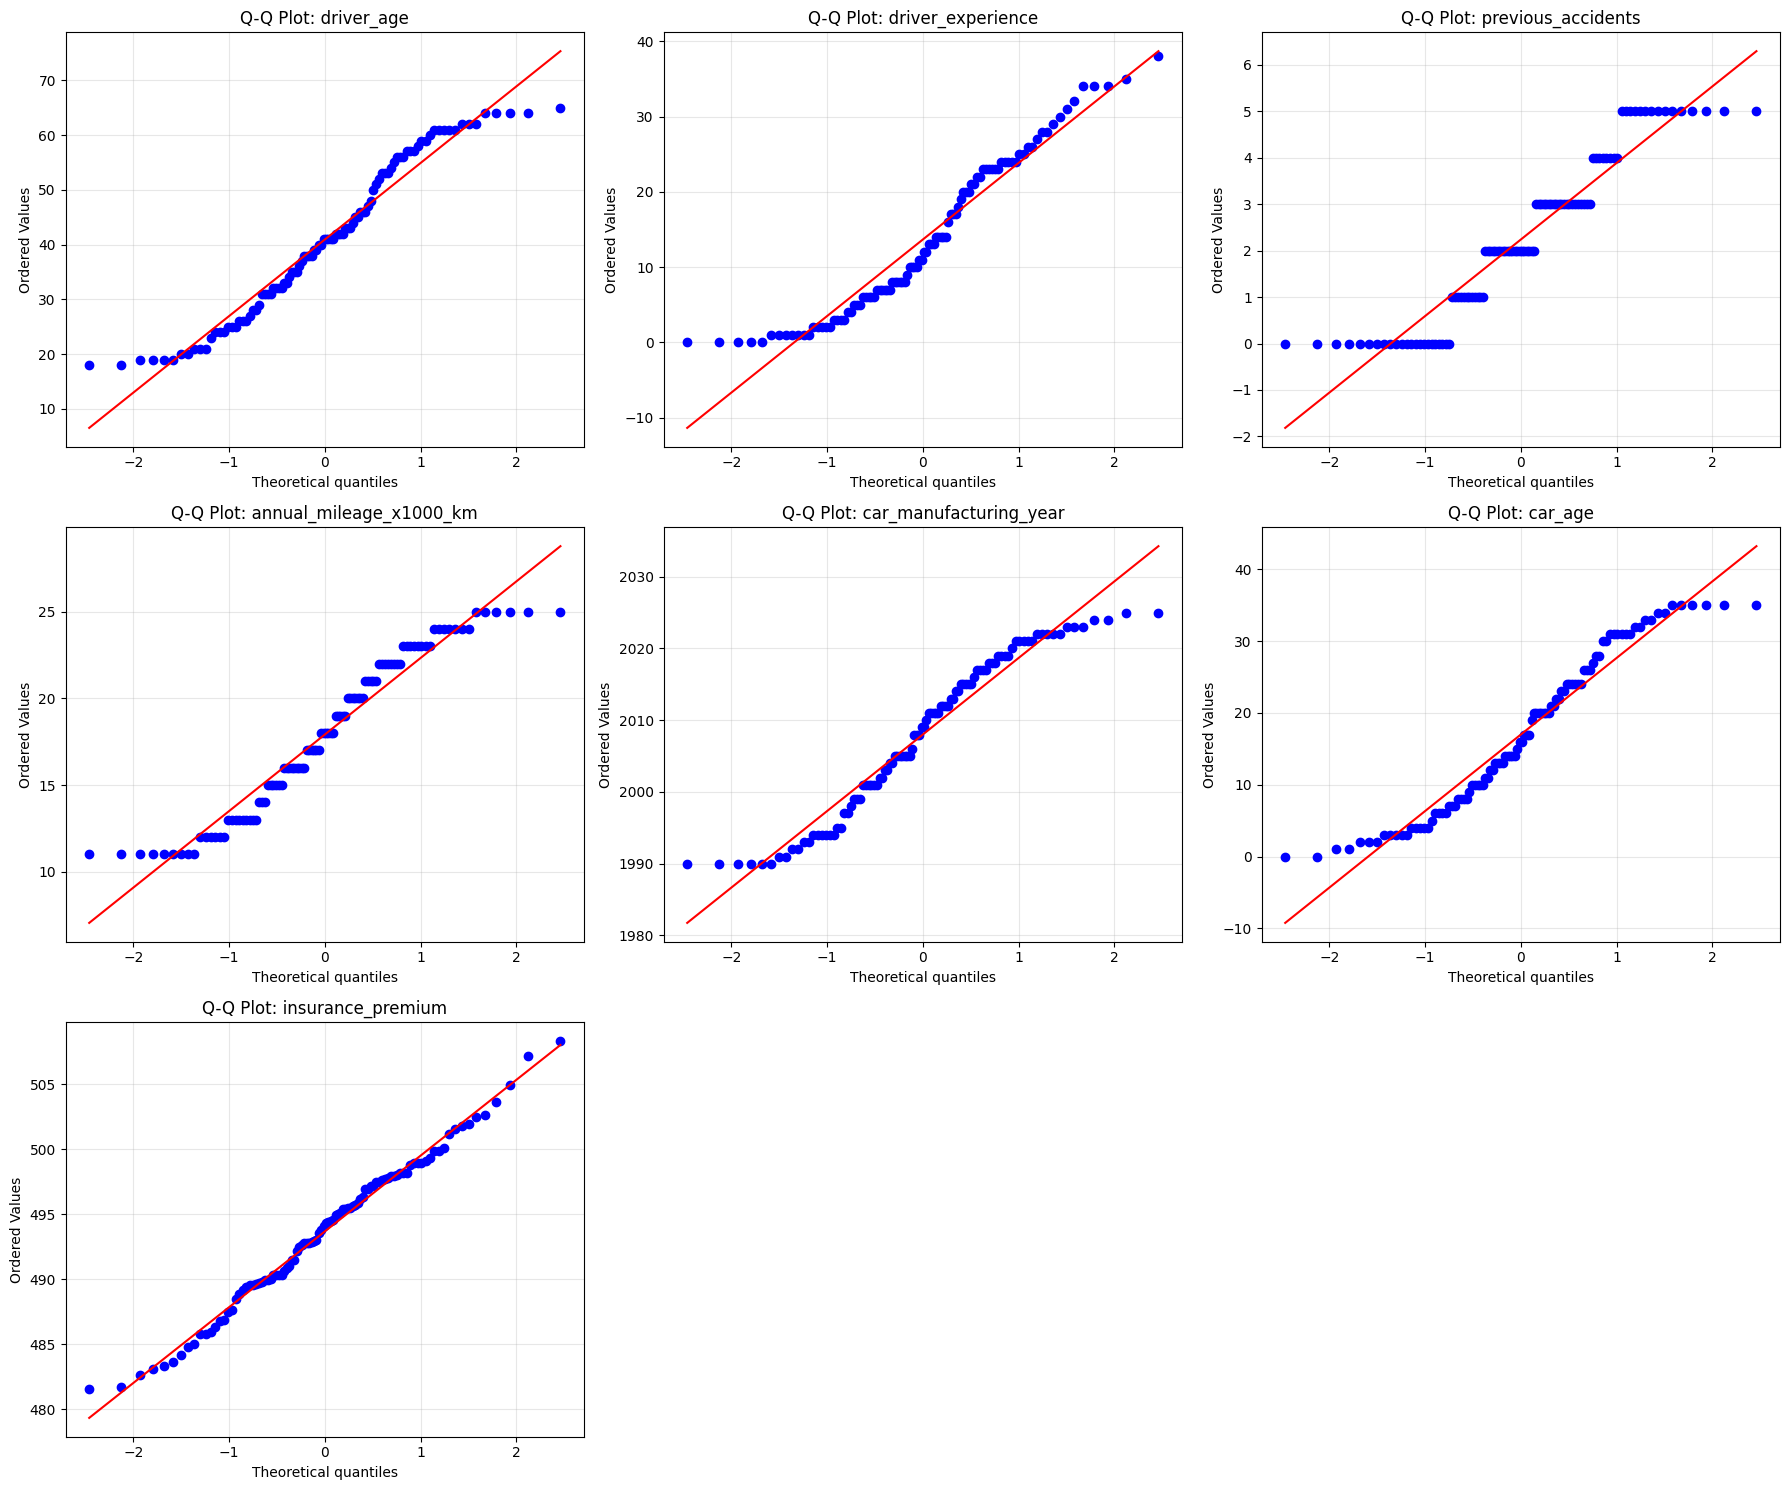

In [0]:
# Q-Q Plots para análise detalhada de normalidade
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, var in enumerate(variaveis):
    if i < len(axes):
        stats.probplot(test[var], dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot: {var}')
        axes[i].grid(True, alpha=0.3)

# Remover eixos extras
for i in range(len(variaveis), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**_Normalidade - Dados treino_**

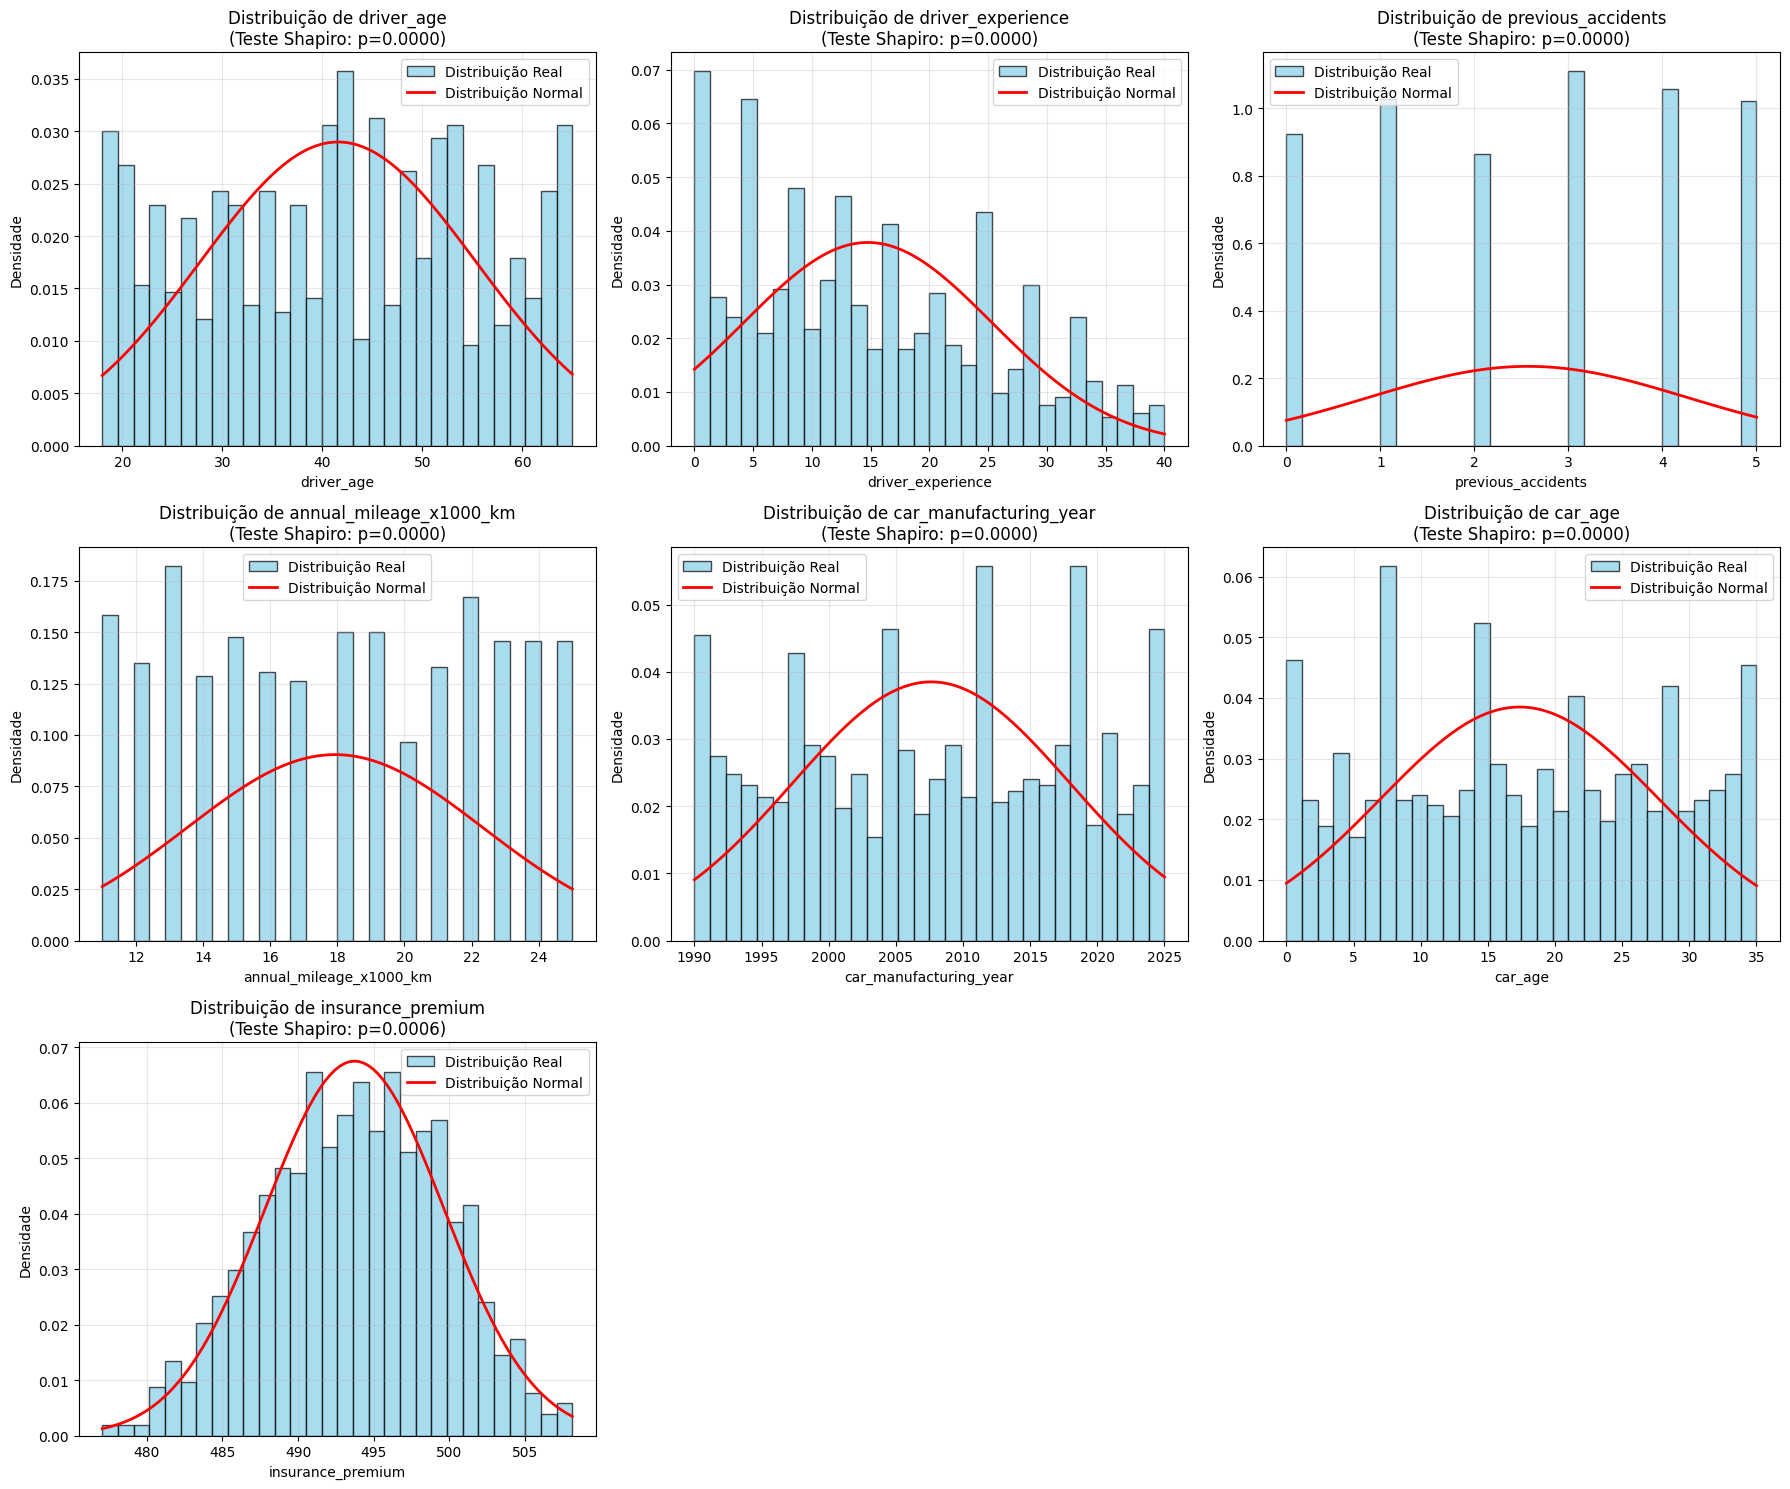

In [0]:
# Configuração para os gráficos
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

# Análise de normalidade para cada variável
for i, var in enumerate(variaveis):
    if i < len(axes):
        # Histograma com curva normal
        data = train[var]
        mu, sigma = data.mean(), data.std()
        
        # Histograma
        n, bins, patches = axes[i].hist(data, bins=30, density=True, alpha=0.7, 
                                      color='skyblue', edgecolor='black', 
                                      label='Distribuição Real')
        
        # Curva normal teórica
        from scipy.stats import norm
        x = np.linspace(data.min(), data.max(), 100)
        y = norm.pdf(x, mu, sigma)
        axes[i].plot(x, y, 'r-', linewidth=2, label='Distribuição Normal')
        
        axes[i].set_title(f'Distribuição de {var}\n(Teste Shapiro: p={stats.shapiro(data)[1]:.4f})')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Densidade')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remover eixos extras
for i in range(len(variaveis), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

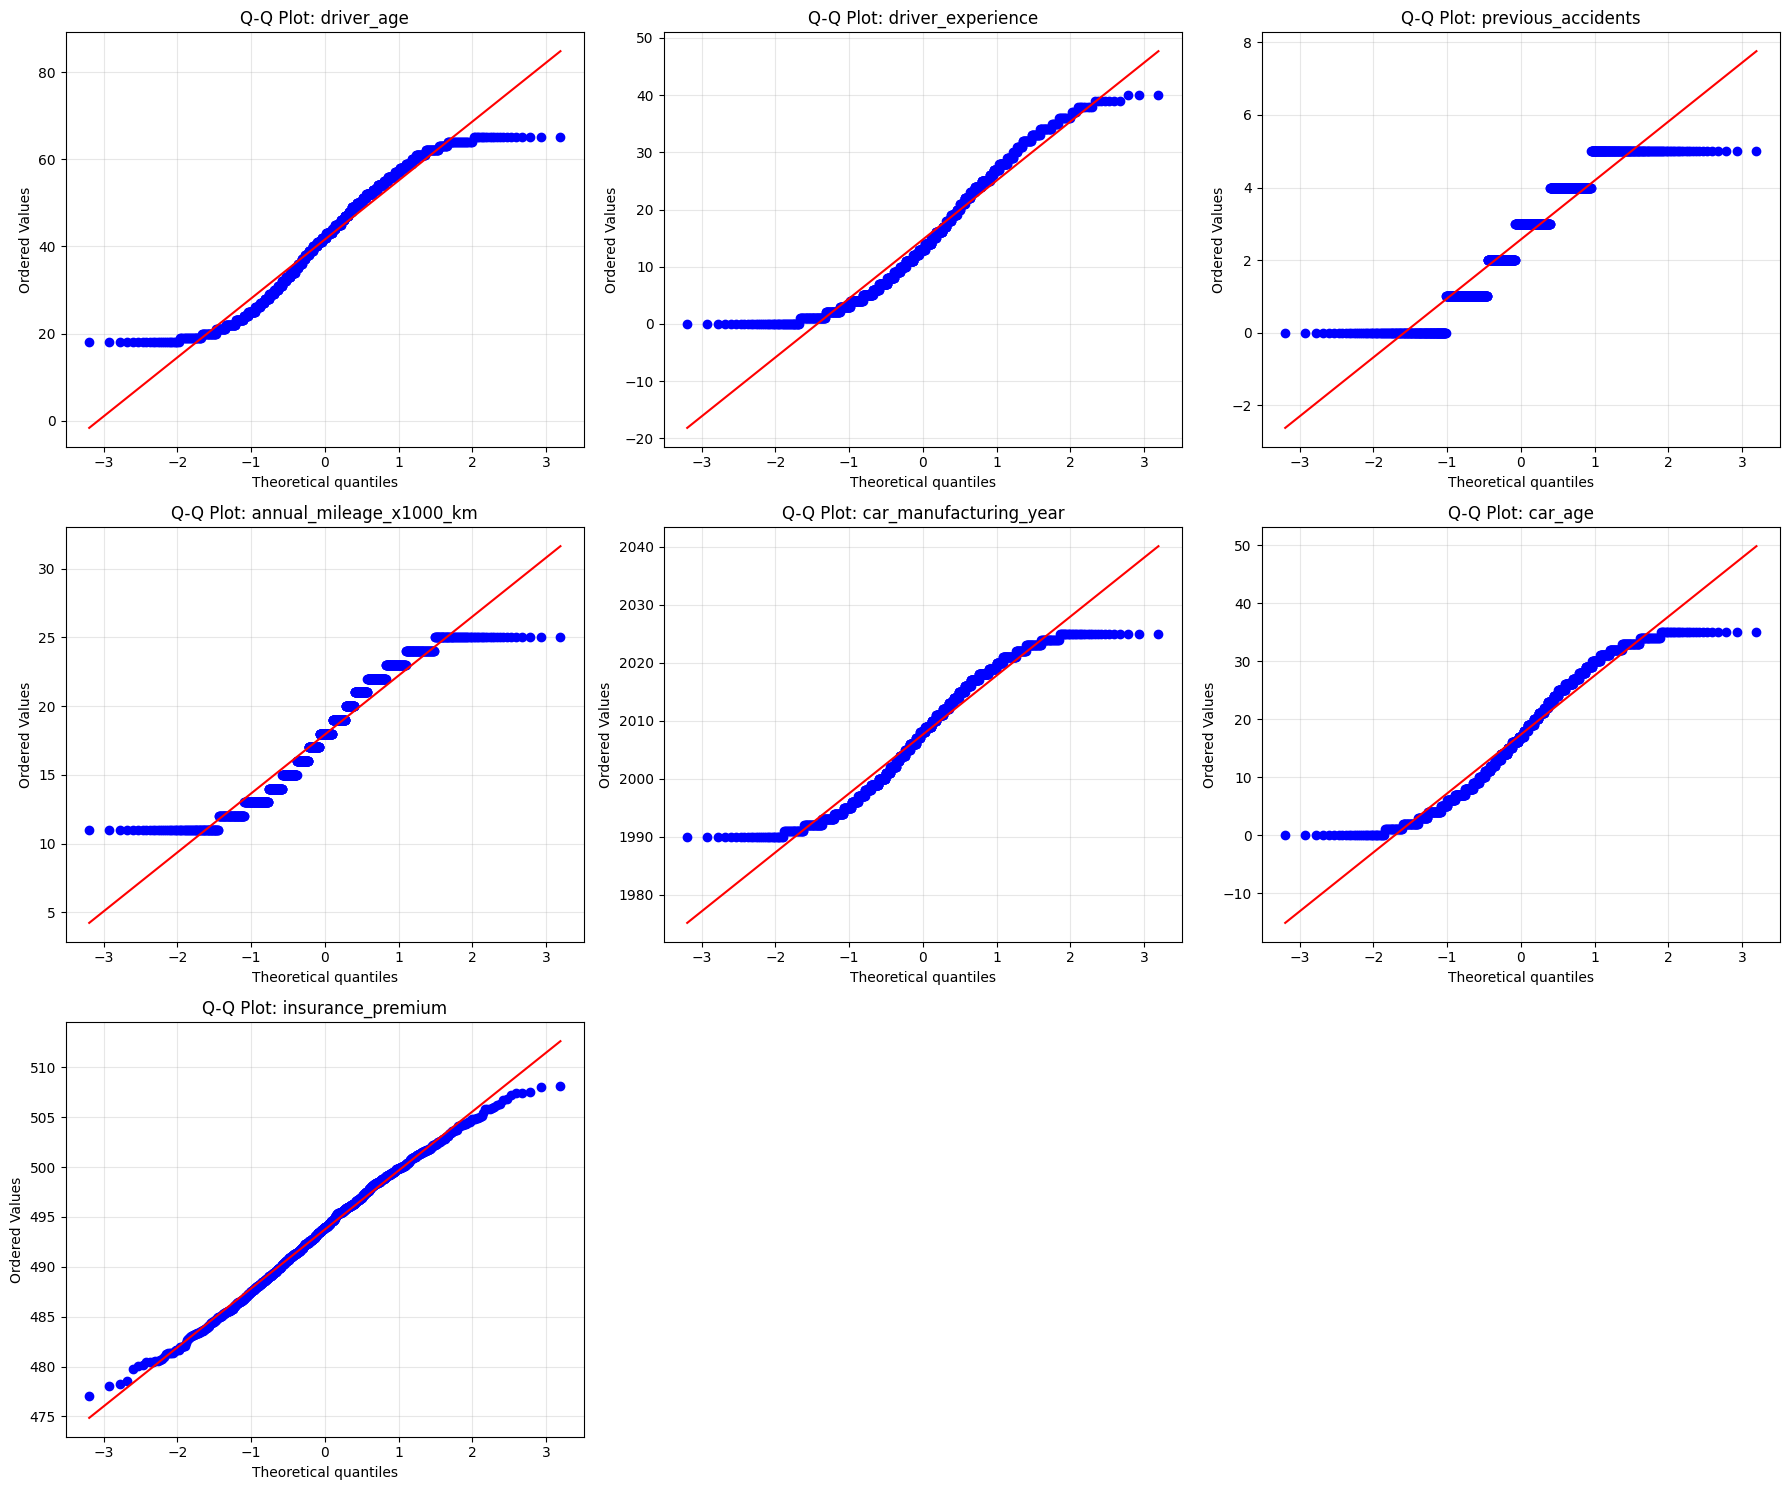

In [0]:
# Q-Q Plots para análise detalhada de normalidade
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, var in enumerate(variaveis):
    if i < len(axes):
        stats.probplot(train[var], dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot: {var}')
        axes[i].grid(True, alpha=0.3)

# Remover eixos extras
for i in range(len(variaveis), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Os resultados das análises indicam que um modelo como o Z-Score teria baixa eficácia identificando os outliers com exceção da coluna 'insurance_premium' que mais se assemelha a uma distribuição normal.

**Método 1 — Z-Score**

O **Z-score** mede o número de desvios padrão que cada valor está distante da média.  
Valores com |Z| > 3 são normalmente considerados **outliers**.  

Calcularemos o Z-score explicitamente para cada coluna numérica:
- z = (x - mean_col) / std_col
- se std_col == 0 (coluna constante), consideramos **nenhum** outlier nessa coluna
- limite clássico: |z| > 3

A função abaixo retorna um DataFrame com as mesmas dimensões,  
contendo **True** para posições consideradas outliers.

In [0]:
def detectar_outliers_zscore_por_coluna(df, limite=3): # Estou usando limite 2.6 pelo maior rigor
    """
    Objetivo: Verificar a existência de Outliers de acordo com o método Z-score.
    Input: Dataframe    
    Output: DataFrame booleano com True onde o valor é outlier.
    """
    num_df = df.select_dtypes(include=np.number)
    outliers = pd.DataFrame(False, index=df.index, columns=num_df.columns)
    
    for col in num_df.columns:
        col_vals = num_df[col]
        mu = col_vals.mean()
        sigma = col_vals.std(ddof=0)  # ddof=0 para população; ddof=1 também é aceitável
        if pd.isna(sigma) or sigma == 0:
            # coluna com variação nula: não marcamos outliers
            outliers[col] = False
            continue
        z = (col_vals - mu) / sigma
        outliers[col] = z.abs() > limite
    return outliers


In [0]:
#Vamos aplicar a função aos nossos dados
outliers_z_train = detectar_outliers_zscore_por_coluna(train)
outliers_z_test = detectar_outliers_zscore_por_coluna(test)

#Exibindo os resultados
print("Percentual de outliers por Z-score (Teste):")
print((outliers_z_test['insurance_premium'].mean() * 100).round(3))
print("Percentual de outliers por Z-score (Treinamento):")
print((outliers_z_train['insurance_premium'].mean() * 100).round(3))

Percentual de outliers por Z-score (Teste):
0.0
Percentual de outliers por Z-score (Treinamento):
0.0


De fato não são encontrados outliers nesta coluna, utilizando o z-score. Talvez reduzindo o limite de 3 para 2.5 seja mais capaz encontrarmos algum outlier, mas isso fugiria do uso normal do método e pode afetar a eficácia do processo.

Não há dúvidas de que é um outlier, sendo os valores mais baixos de insurance premium. ambos sem 

**Método 2 — IQR** (Intervalo Interquartil)

O **IQR (Interquartile Range)** é a diferença entre o terceiro e o primeiro quartil (Q3 - Q1).  
Valores abaixo de **Q1 - 1.5 × IQR** ou acima de **Q3 + 1.5 × IQR** são considerados outliers.

A função abaixo identifica esses pontos e retorna um DataFrame booleano.

In [0]:
def iqr(df, colunas=None):
    """
    Objetivo: Calcula IQR 
    Input: DataFrame 
    Output: Mostra gráficos simples
    """
    if colunas is None:
        colunas = df.select_dtypes(include=[np.number]).columns.tolist()
        if 'Unnamed: 0' in colunas:
            colunas.remove('Unnamed: 0')
    
    resultados = []
    
    for coluna in colunas:
        data = df[coluna]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        
        outliers = data[(data < lim_inf) | (data > lim_sup)]
        n_outliers = len(outliers)
        
        resultados.append({
            'coluna': coluna,
            'outliers': n_outliers,
            'percentual': (n_outliers / len(data)) * 100
        })
    
    # Gráfico simples
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico 1: Número de outliers
    df_resultados = pd.DataFrame(resultados)
    ax1.bar(df_resultados['coluna'], df_resultados['outliers'], color='lightcoral')
    ax1.set_title('Número de Outliers por Variável')
    ax1.tick_params(axis='x', rotation=45)
    
    # Gráfico 2: Boxplots
    df[colunas].boxplot(ax=ax2)
    ax2.set_title('Boxplots - Visualização de Outliers')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(resultados)


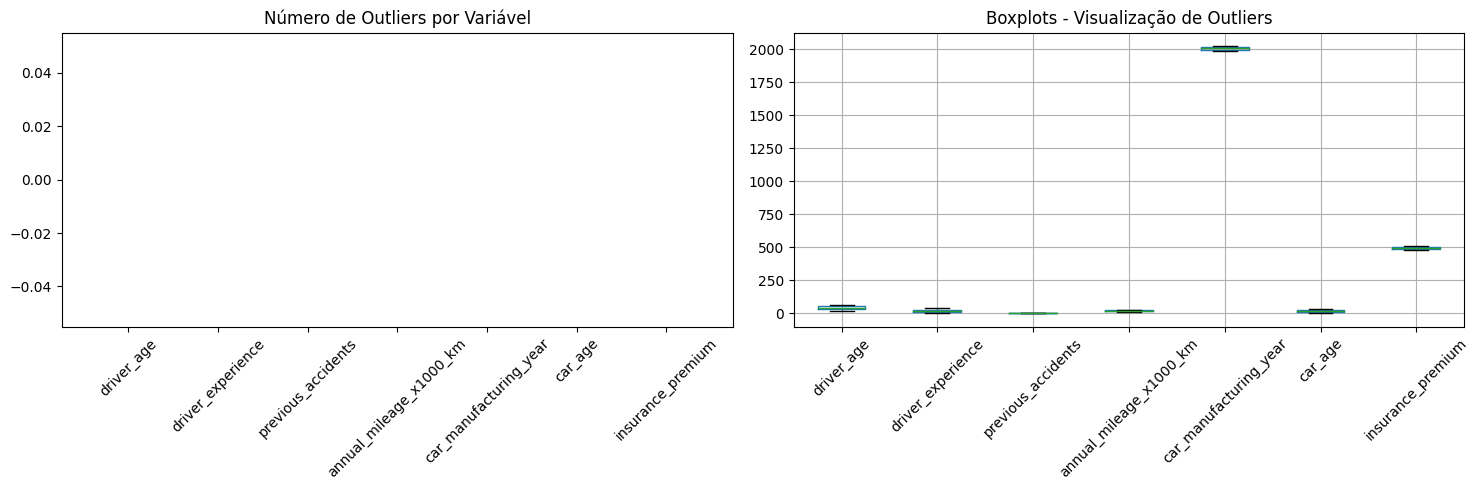

In [0]:
# Usar a função
resultados = iqr(train)

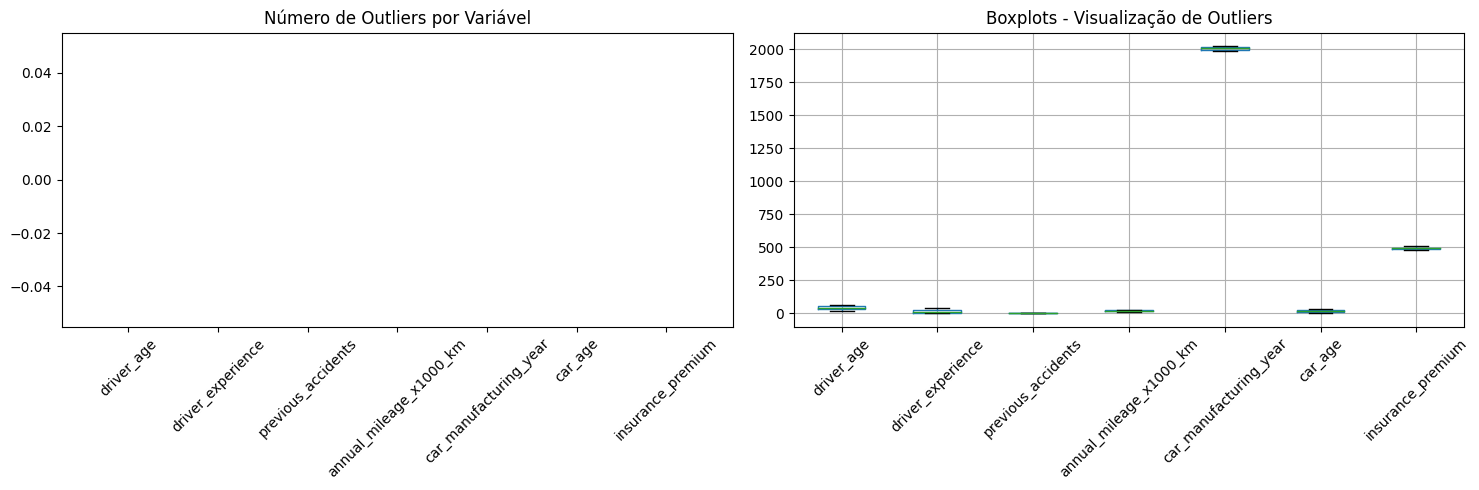

In [0]:
#usando a função para o set de treinamento
resultados = iqr(test)

Portanto, nossos sets de dados não possuiam outliers para serem tratados, como foi confirmado. 

In [0]:
#Salvando os dados na camada silver 
train.to_csv(f"{base_path}/DataLake/gold/car_insurance_premium_dataset.csv")
test.to_csv(f"{base_path}/DataLake/gold/car_insurance_premium_dataset_TEST.csv")

___

**5. Lidar com dados categóricos. Descreva o tratamento que você aplicou.**

Nessa parte do trabalho vou realizar tarefas **apenas no dataset de treinamento**, dado aviso do prof. Nélio de que era em cima dele que deveria ser feito o trabalho. Antes de iniciar qualquer processamento, é fundamental entender a estrutura e composição dos nossos datasets. Vamos carregar os dados e realizar uma análise inicial para compreender as dimensões, tipos de variáveis e distribuição básica.



In [0]:
# Carregar dados
df_train = pd.read_csv(f'{base_path}/DataLake/gold/car_insurance_premium_dataset.csv')

# Remover coluna de índice
df_train = df_train.drop('Unnamed: 0', axis=1)

In [0]:
# Classificação das variáveis
variaveis = {
    'target': ['insurance_premium'],
    'numericas_continuas': ['driver_age', 'driver_experience', 'annual_mileage_x1000_km'],
    'numericas_discretas': ['previous_accidents', 'car_manufacturing_year', 'car_age'],
    'categoricas': ['previous_accidents']
}


Agora poderemos categorizar cada variável conforme sua natureza. O que nos guiará nas estratégias de pré-processamento específicas para cada tipo de dado.

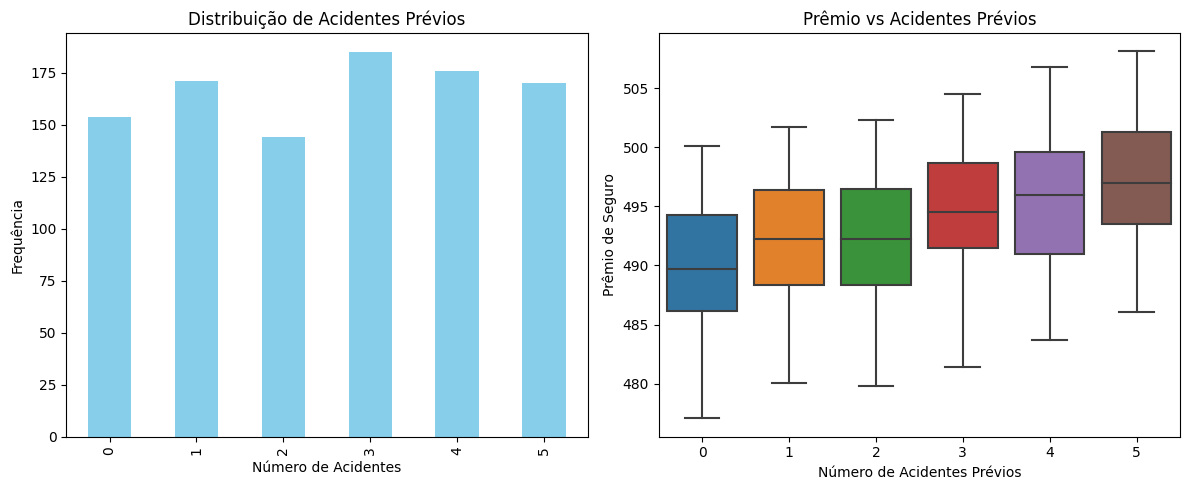

In [0]:
accident_counts = df_train['previous_accidents'].value_counts().sort_index()

plt.figure(figsize=(12, 5))

# Primeira imagem - Gráfico de barras
plt.subplot(1, 2, 1)
accident_counts.plot(kind='bar', color='skyblue')
plt.title('Distribuição de Acidentes Prévios')
plt.xlabel('Número de Acidentes')
plt.ylabel('Frequência')

# Segunda imagem - Boxplot com seaborn
plt.subplot(1, 2, 2)
sns.boxplot(x='previous_accidents', y='insurance_premium', data=df_train)
plt.title('Prêmio vs Acidentes Prévios')
plt.xlabel('Número de Acidentes Prévios')
plt.ylabel('Prêmio de Seguro')

plt.tight_layout()
plt.show()

Analisamos a distribuição da variável de acidentes prévios e sua influência no valor da variável 'insurance_premium'. Conseguimos ver claramente um crescimento do prêmio do seguro conforme o número de acidentes passados cresce no gráfico, o que prova a visão intuitiva que temos de que pessoas que sofreram muitos acidentes tem maior risco de sofrer novos acidentes, tornando o seguro mais caro.

___

**6. Fazer EDA (Análise Exploratória de Dados)**

Muita vezes a análize exploratória começa com a estatística descritiva dos dados, não só por ser o conjunto de informações mais básicos que se pode tirar do dataset mas também porque se faz valer a definição da palavra.

In [0]:
#Obtendo descrição dos dados
df_train.describe()

**Percepções acerca das Variáveis**
- Idade dos Condutores (41.6 ± 13.8 anos) - um desvio ruim
- Range completo: 18-65 anos
- Presença significativa de iniciantes (mínimo: 0 anos)
- Prêmios de Seguro concentrado - Target (493.7 ± 5.9)
- Frota diversificada: 0-35 anos
- Tendência para veículos mais antigos

**Relações:** A seguir um conjunto de gráficos levantados afim de entender como está ocorrendo tanto a distribuição do prêmio e sua relação com moda e média como também algumas relações de variáveis

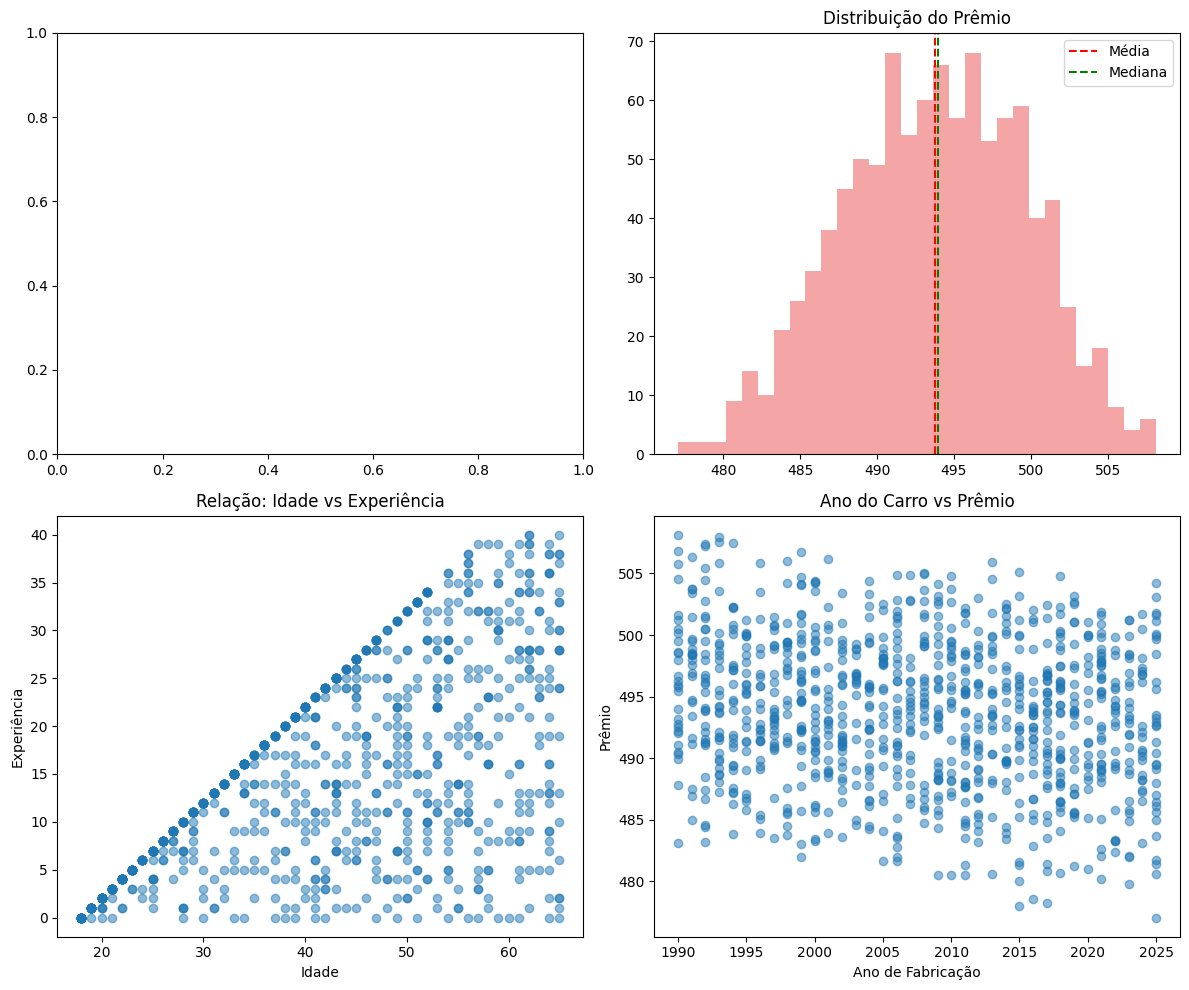

In [0]:
# Análise de Outliers e Valores Extremos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribuição do target com estatísticas
axes[0, 1].hist(df_train['insurance_premium'], bins=30, alpha=0.7, color='lightcoral')
axes[0, 1].axvline(df_train['insurance_premium'].mean(), color='red', linestyle='--', label='Média')
axes[0, 1].axvline(df_train['insurance_premium'].median(), color='green', linestyle='--', label='Mediana')
axes[0, 1].set_title('Distribuição do Prêmio')
axes[0, 1].legend()

# Relação experiência vs idade
axes[1, 0].scatter(df_train['driver_age'], df_train['driver_experience'], alpha=0.5)
axes[1, 0].set_xlabel('Idade')
axes[1, 0].set_ylabel('Experiência')
axes[1, 0].set_title('Relação: Idade vs Experiência')

# Ano do carro vs prêmio
axes[1, 1].scatter(df_train['car_manufacturing_year'], df_train['insurance_premium'], alpha=0.5)
axes[1, 1].set_xlabel('Ano de Fabricação')
axes[1, 1].set_ylabel('Prêmio')
axes[1, 1].set_title('Ano do Carro vs Prêmio')

plt.tight_layout()
plt.show()

A **distribuição do prêmio** lembra bem uma normal com a mediana praticamente coincidindo com a moda inclusive. 

A **relação entre idade e experiência** tem um formato interessante, o grupo de indivíduos que tirou a carteira de habilitação na idade mínima formam uma função afim que traça uma reta de 45° no gráfico e, embora os outros indivíduos tenham iniciado sua experiência em fases diferentes da vida, podemos perceber que a anomalia de erro de registro "experiência > idade" ou "experiência > idade + idade mínima de dirigir" não ocorreu como esperávamos uma vez que não encontramos outliers ao buscá-los. 

A **relação entre o Ano do carro e o Prêmio** também forma um padrão que pode ser interpretado. Embora ao longo das possibilidades de ano de fabricação dos veículos, podemos perceber que o prêmio médio de cada ano de referência "_parece tender_" a diminuir conforme os modelos estão na parte mais recente do eixo 'Ano de Fabricação', Conforme demonstro no gráfico abaixo.


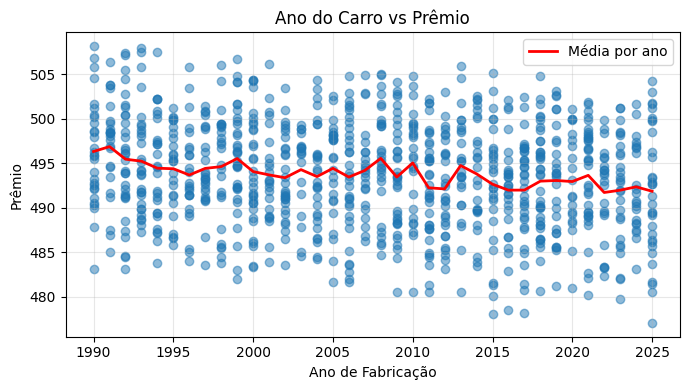

In [0]:
# Criar apenas uma figura
plt.figure(figsize=(7, 4))

# Scatter plot
plt.scatter(df_train['car_manufacturing_year'], df_train['insurance_premium'], alpha=0.5)

# Calcular a média do prêmio por ano
media_por_ano = df_train.groupby('car_manufacturing_year')['insurance_premium'].mean().reset_index()

# Ordenar por ano para garantir que a linha seja plotada corretamente
media_por_ano = media_por_ano.sort_values('car_manufacturing_year')

# Plotar a linha da média
plt.plot(media_por_ano['car_manufacturing_year'], media_por_ano['insurance_premium'], 
         color='red', linewidth=2, label='Média por ano')

plt.xlabel('Ano de Fabricação')
plt.ylabel('Prêmio')
plt.title('Ano do Carro vs Prêmio')
plt.legend()  # Adicionar legenda para identificar a linha
plt.grid(True, alpha=0.3)  # Opcional: adicionar grid para melhor visualização

plt.tight_layout()
plt.show()

Com a luz sobre o valor da média, agora percebemos que parece haver mesmo esta diferença mas com algumas oscilações. A fim de teste vou levantar a hipótese h:'o prêmio para cada carro é mais de acordo com o quão antigo ele é, mas pode oscilar pela rodagem'. Para este teste vou aplicar um modelo linear simples para teste.

In [0]:
# Modelo linear
X_premio_ano = sm.add_constant(df_train[['car_age', 'annual_mileage_x1000_km']])
y_premio_ano = df_train['insurance_premium']
modelo_premio = sm.OLS(y_premio_ano, X_premio_ano).fit()
print(modelo_premio.summary())

                            OLS Regression Results                            
Dep. Variable:      insurance_premium   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     15.41
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           2.55e-07
Time:                        16:17:35   Log-Likelihood:                -3179.8
No. Observations:                1000   AIC:                             6366.
Df Residuals:                     997   BIC:                             6380.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

  - Idade do Carro (car_age): 0.091
  - Estatisticamente significativa (p < 0.001)

Para cada ano adicional na idade do carro, o prêmio aumenta em ≈ 0.09 unidades, então esta é uma variável significativa.
Efeito positivo, porém pequeno em magnitude.

  - Quilometragem Anual (annual_mileage_x1000_km): 0.0290
  - Não significativa (p = 0.488 > 0.05)
  - O efeito não é estatisticamente diferente de zero. Seu intervalo de confiança [-0.053, 0.111] inclui zero

Portanto concluímos que a idade do veículo é estatísticamente relevante, embora pouco, no prêmio. E caso haja uma estatística que varia esse prêmio médio por idade dos veículos, certamente não deve ser a rodagem anual.


___

Agora um boxplot vizual das nossas colunas para demonstrá-las

DETECÇÃO DE OUTLIERS (Boxplots):


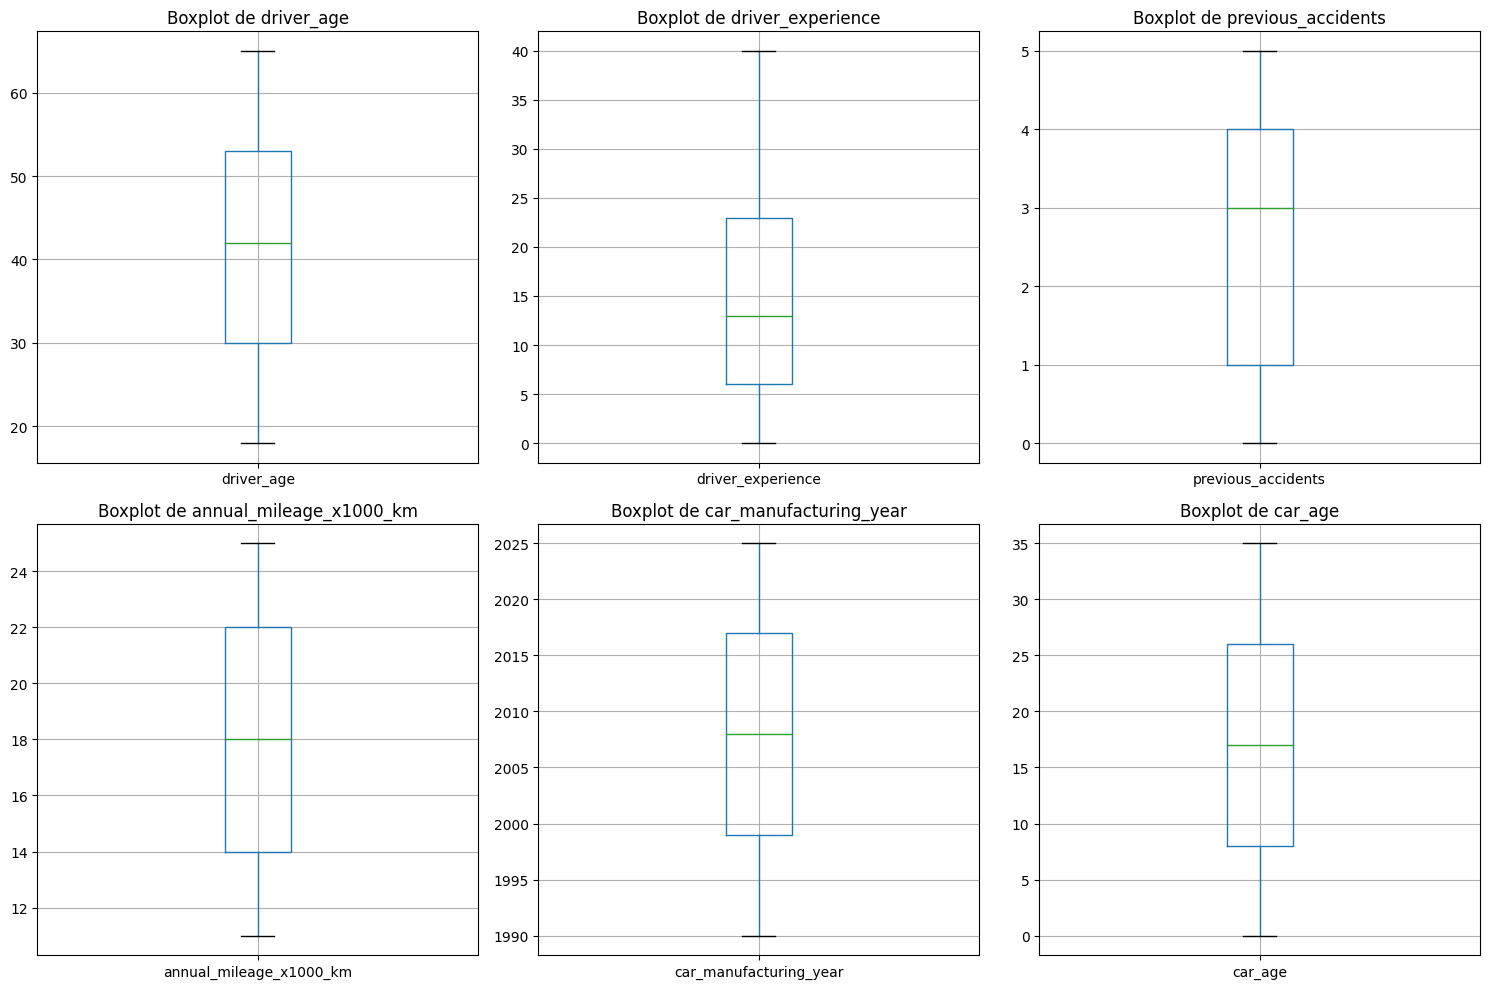

In [0]:
def box_plots(df):
    """
    Objetivo: Obter boxplots de variáveis numéricas com outliers destacados
    Input: Dataframe
    Output: Boxplots com pontos de outliers
    """
    variaveis_numericas = df.columns
    
    # Boxplots para identificar outliers
    print("DETECÇÃO DE OUTLIERS (Boxplots):")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, coluna in enumerate(variaveis_numericas[1:7]):
        # Criar boxplot
        df.boxplot(column=coluna, ax=axes[i])
        axes[i].set_title(f'Boxplot de {coluna}')
        
        # Calcular e plotar outliers como pontos individuais
        Q1 = df[coluna].quantile(0.25)
        Q3 = df[coluna].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identificar outliers
        outliers = df[(df[coluna] < lower_bound) | (df[coluna] > upper_bound)]
        
        # Plotar outliers em vermelho
        if not outliers.empty:
            # Posicionar os pontos na horizontal (valor x baseado no índice)
            x_positions = np.random.normal(1, 0.04, size=len(outliers))  # Pequeno jitter
            axes[i].scatter(x_positions, outliers[coluna], color='red', alpha=0.6, s=30)
            
            # Adicionar contagem de outliers no gráfico
            axes[i].text(0.05, 0.95, f'Outliers: {len(outliers)}', 
                        transform=axes[i].transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="white"))
    
    plt.tight_layout()
    plt.show()

# Executar EDA
box_plots(df_train)

Provando que embora até possa haver valores extremos, não são outliers estatísticos


Agora, como um dos meus apoios vizuais favoritos vamos demonstrar a funcionalidade da matriz de correlação aplicada ao problema.


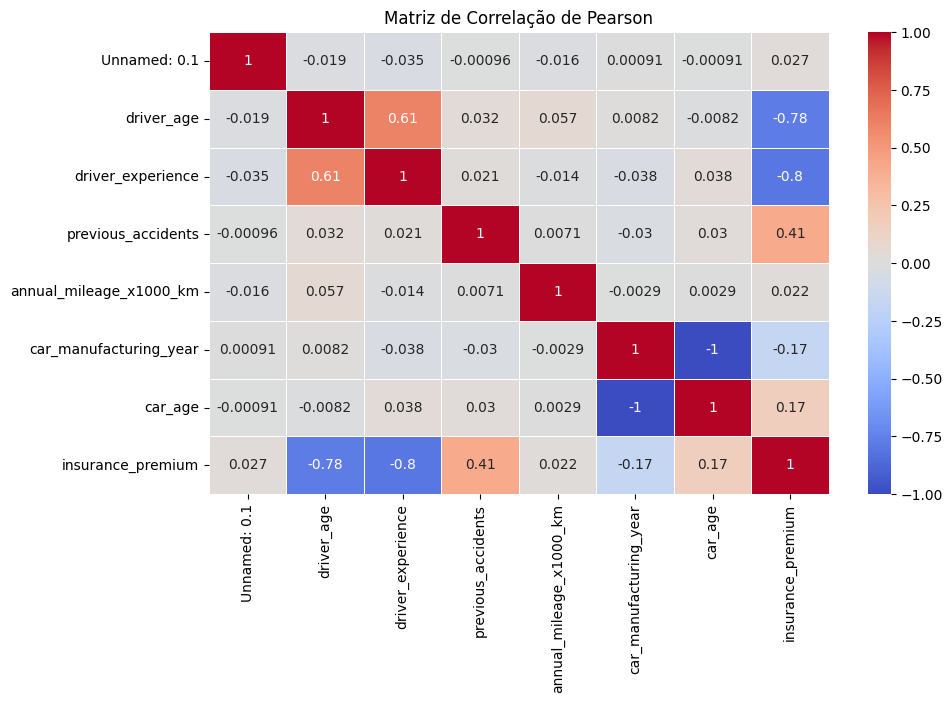

In [0]:
def correlation(df):
    """
    Objetivo: Fazer uma matriz de correlação dos dados de um df
    Input: df
    Output: plot da matriz de correlação
    """
    # Correlação numérica
    corr = df_train.corr(numeric_only=True)

    # Mapa de calor
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Matriz de Correlação de Pearson')
    plt.show()

correlation(df_train)

**Interpretação:**
- Valores próximos de 1 ou -1 indicam correlação forte.
- Valores próximos de 0 indicam fraca ou nenhuma relação linear.

A matriz de correlação nos ajuda a identificar relações lineares entre as variáveis. Algumas já esperadas, como a correlação entre 'driver_age' e 'driver_experience', mas também podemos  perceber a como 'previous_accidents' tem correlação positiva com 'insurance_premium' mas 'driver_experience' e, por obrigação, 'driver_age' tem correlação negativa com esta variável. Vejamos um exemplo a seguir com o t-test:

In [0]:
df_query_not_hiiters = df_train[df_train['previous_accidents'] <= 2]['insurance_premium']
df_query_hitters = df_train[df_train['previous_accidents'] > 2]['insurance_premium']

print(f"Poucos acidentes (<=2): n={len(df_query_not_hiiters)}")
print(f"Muitos acidentes (>2): n={len(df_query_hitters)}")

t_stat, p_value = ttest_ind(df_query_not_hiiters, df_query_hitters, equal_var=False)

alpha = 0.05
if p_value < alpha:
    print("Diferença ESTATISTICAMENTE SIGNIFICANTE entre os grupos")
else:
    print("Diferença NÃO significativa entre os grupos")

Poucos acidentes (<=2): n=469
Muitos acidentes (>2): n=531
Diferença ESTATISTICAMENTE SIGNIFICANTE entre os grupos


Usando a estatística t-test conseguimos verificar que existe diferença significativa entre os grupos de pessoas que sofreram muitos ou poucos acidentes no passado, em relação a quanto é estipulado como valor de prêmio, de acordo com nossa base de dados.

In [0]:
# Modelo linear simples para o prêmio
X_premio = sm.add_constant(df_train[['driver_experience', 'previous_accidents', 
                                  'annual_mileage_x1000_km', 'car_manufacturing_year']])
y_premio = df_train['insurance_premium']
modelo_premio = sm.OLS(y_premio, X_premio).fit()
print(modelo_premio.summary())

                            OLS Regression Results                            
Dep. Variable:      insurance_premium   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     1586.
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:33:57   Log-Likelihood:                -2196.0
No. Observations:                1000   AIC:                             4402.
Df Residuals:                     995   BIC:                             4427.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Variáveis Significativas:
- Experiência do Condutor (p=0.000)
- Coeficiente: -0.4592
- Mais experiência → Prêmio MENOR (relação forte negativa)
- Acidentes Prévios (p=0.000)
- Coeficiente: +1.4682
- Mais acidentes → Prêmio MAIOR (impacto forte positivo)
- Ano de Fabricação (p=0.000)
- Coeficiente: -0.1086
- Carro mais novo → Prêmio MENOR (relação moderada)

Tudo isso é muito interessante por poder ser observado no gráfico de correlação e se confirmar nos testes estatísticos.

**Bônus: Turkoises e Skewness**

_Interpretação do Skewness:_
  - Valor negativo (-0.949): Assimetria à esquerda
  - Intensidade: Moderada (geralmente considera-se:
  - |Skew| < 0.5: aproximadamente simétrica
  - 0.5 < |Skew| < 1: moderadamente assimétrica
  - |Skew| > 1: fortemente assimétrica)

O que significa:
Cauda mais longa à esquerda, Moda > Mediana > Média, mais valores concentrados no lado direito da distribuição, valores baixos são mais frequentes que valores altos

_Interpretação da Kurtosis:_
  - Kurtosis = 3: Distribuição normal (mesocúrtica)
  - Kurtosis > 3: Distribuição mais "pontiaguda" que a normal (leptocúrtica)
  - Kurtosis < 3: Distribuição mais "achatada" que a normal (platicúrtica)

No caso (3.051): Levemente leptocúrtica - pouquíssimo acima de 3. Distribuição muito próxima da normal em termos de curtose.

Agora para verificarmos, vamos olhar com olhos mais gráficos.



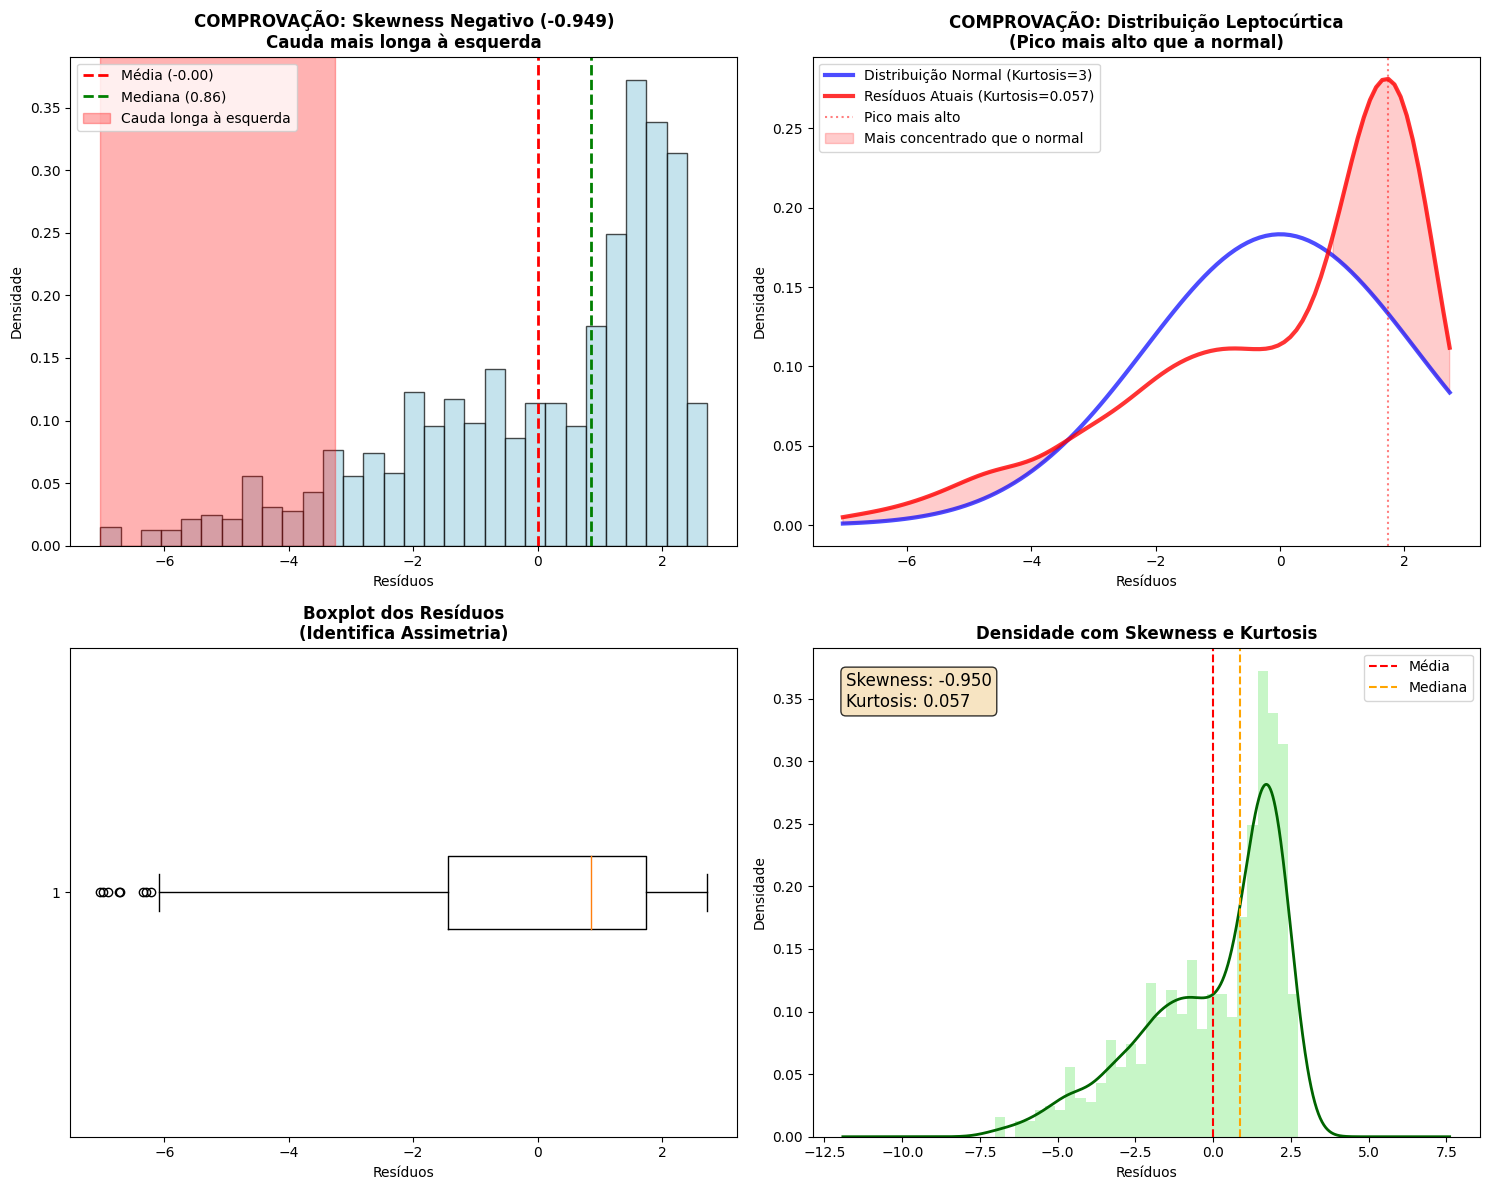

In [0]:
# Obter resíduos do modelo
residuos = modelo_premio.resid
skew = residuos.skew()
kurtosis = residuos.kurtosis()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# GRÁFICO 1: Skewness - Histograma com cauda destacada
axes[0, 0].hist(residuos, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
axes[0, 0].axvline(residuos.mean(), color='red', linestyle='--', linewidth=2, label=f'Média ({residuos.mean():.2f})')
axes[0, 0].axvline(residuos.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana ({residuos.median():.2f})')

# Adicionar linha mostrando a cauda longa à esquerda
limite_cauda = np.percentile(residuos, 10)
axes[0, 0].axvspan(residuos.min(), limite_cauda, alpha=0.3, color='red', label='Cauda longa à esquerda')

axes[0, 0].set_title('COMPROVAÇÃO: Skewness Negativo (-0.949)\nCauda mais longa à esquerda', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Resíduos')
axes[0, 0].set_ylabel('Densidade')
axes[0, 0].legend()

# GRÁFICO 2: Kurtosis - Comparação de densidades
x = np.linspace(residuos.min(), residuos.max(), 100)
y_normal = stats.norm.pdf(x, residuos.mean(), residuos.std())
y_actual = stats.gaussian_kde(residuos)(x)

axes[0, 1].plot(x, y_normal, 'b-', linewidth=3, label='Distribuição Normal (Kurtosis=3)', alpha=0.7)
axes[0, 1].plot(x, y_actual, 'r-', linewidth=3, label=f'Resíduos Atuais (Kurtosis={kurtosis:.3f})', alpha=0.8)

# Destacar a região onde é mais pontiaguda
pico_max = x[np.argmax(y_actual)]
axes[0, 1].axvline(pico_max, color='red', linestyle=':', alpha=0.5, label='Pico mais alto')
axes[0, 1].fill_between(x, y_actual, y_normal, where=(y_actual > y_normal), 
                       color='red', alpha=0.2, label='Mais concentrado que o normal')

axes[0, 1].set_title('COMPROVAÇÃO: Distribuição Leptocúrtica\n(Pico mais alto que a normal)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Resíduos')
axes[0, 1].set_ylabel('Densidade')
axes[0, 1].legend()

# GRÁFICO 3: Boxplot para mostrar assimetria
axes[1, 0].boxplot(residuos, vert=False)
axes[1, 0].set_title('Boxplot dos Resíduos\n(Identifica Assimetria)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Resíduos')

# GRÁFICO 4: Densidade com medidas
axes[1, 1].hist(residuos, bins=30, density=True, alpha=0.5, color='lightgreen')
residuos.plot.density(ax=axes[1, 1], linewidth=2, color='darkgreen')
axes[1, 1].axvline(residuos.mean(), color='red', linestyle='--', label=f'Média')
axes[1, 1].axvline(residuos.median(), color='orange', linestyle='--', label=f'Mediana')

# Adicionar texto com skewness e kurtosis
textstr = f'Skewness: {skew:.3f}\nKurtosis: {kurtosis:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
axes[1, 1].text(0.05, 0.95, textstr, transform=axes[1, 1].transAxes, fontsize=12,
                verticalalignment='top', bbox=props)

axes[1, 1].set_title('Densidade com Skewness e Kurtosis', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Resíduos')
axes[1, 1].set_ylabel('Densidade')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

**Figura 01:** Podemos perceber o Skewness negativo e também a relação Moda > Mediana > Média

**Figura 02:** Podemos ver a natureza leptocurtica da distribuição.

**Figura 03:** Boxplot dos resíduos destaca a assimetria

**Figura 04:** Percebemos: Quão assimétrica é a distribuição (Skewness) e Quão "pontiaguda" é a distribuição  (Kurtosis).

___

**7. Descreva os tipos de dados: float, int64, integer, ...**

In [0]:
# Análise de Valores Únicos
print("ANÁLISE DE VALORES ÚNICOS POR COLUNA:")
for coluna in df_train.columns:
    print(f"{coluna}: {df_train[coluna].nunique()} valores únicos")

ANÁLISE DE VALORES ÚNICOS POR COLUNA:
Unnamed: 0.1: 1000 valores únicos
driver_age: 48 valores únicos
driver_experience: 41 valores únicos
previous_accidents: 6 valores únicos
annual_mileage_x1000_km: 15 valores únicos
car_manufacturing_year: 36 valores únicos
car_age: 36 valores únicos
insurance_premium: 414 valores únicos


- previous_accidents confirma-se como variável categórica ideal para encoding
- Demais variáveis comportam-se como numéricas contínuas
- insurance_premium diversificado com 414 valores únicos - bom para regressão
- Nenhuma variável constante - todas contribuem com informação
- Cardinalidade adequada para modelagem, sem necessidade de agrupamento ou redução dimensional.

In [0]:
def data_type(df):
    """
    Objetivo: Identificar o tipo dos dados de um df
    Ijnput: df
    Output: print do tipo dos dados
    """
    
    # Tipos de Dados
    print("\n TIPOS DE DADOS:")
    print(df.dtypes)
    
    # Shape do Dataset
    print(f"FORMA DO DATASET:")
    print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")
    

# Executar EDA
data_type(df_train)


 TIPOS DE DADOS:
Unnamed: 0.1                 int64
driver_age                   int64
driver_experience            int64
previous_accidents           int64
annual_mileage_x1000_km      int64
car_manufacturing_year       int64
car_age                      int64
insurance_premium          float64
dtype: object
FORMA DO DATASET:
Linhas: 1000, Colunas: 8


Todas as colunas são de dados inteiros (int64), com excessão da 'insurance_premium' que é float (float64).

Obrigado pela atenção.